### Полиномиальные модели

#### Цель работы

На практике познакомиться с моделями полиномиальной регрессии и классификации, понять влияние степени полинома на вычислительную сложность и точность модели.

#### Содержание работы

1. Загрузите учебный набор данных для регрессии "gen_regression".
1. Постройте модель парной линейной регрессии, оцените ее эффективность, изобразите модель на графике.
1. Постройте модель полиномиальной регрессии второго порядка. Сравните ее эффективность с первой моделью.
1. Загрузите набор данных для классификации "gen_classification". 
1. Постройте линейную классификацию, изобразите ее на графике и оцените точность.
1. Введите в данные признаки третьего порядка и постройте классификацию. Сравните с предыдущей моделью.
1. Загрузите набор данных, содержащий данные о продаже домов в округе King county, США.
1. Постройте на этом датасете линейную модель и полиномиальную второго порядка. Изобразите на графике и сравните эффективность.

#### Методические указания

Начнем как всегда с импорта необходимых библиотек:

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Парная регрессия
Прочитаем первый датасет по ссылке:

In [171]:
data = pd.read_csv("data/gen_regression.csv")

Выведем его первые строчки на экран, чтобы убедиться, что он был прочитан правильно и познакомиться с его структурой:

In [172]:
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


Это датасет для решения задачи парной регрессии. Мы видим один столбец, названный _x_ и один столбец _y_. Оба они выражены в численном виде.
Видим, что датасет прочитался неправильно. Однако сейчас нам проще не исправлять код чтения, а сразу выделить необходимые столбцы в переменные:

In [173]:
X = data.x
y = data.y

Так как датасет парный, мы можем изобразить зависимость между единственным атрибутом и целевой переменной на графике:

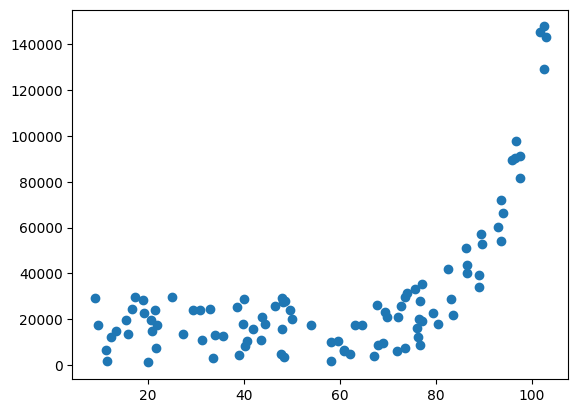

In [174]:
plt.scatter(X, y)

Мы должны увидеть график, подобный такому.

Здесь мы видим наличие нелинейной зависимости между атрибутом и целевой переменной. Мы пока не знаем, какова именно эта зависимость и какая функция его приближает лучше всего. Мы будем пробовать строить полиномы разных степеней и смотреть, насколько точной получатся такие модели. Для эксперимента построим модель линейной регрессии. Для этого импортируем соответствующий класс из библиотеки и обучим модель:

In [175]:
from sklearn.linear_model import LinearRegression
X = pd.DataFrame(X)
linear = LinearRegression().fit(X, y)

Обратите внимание, что все объекты _sklearn_ предполагают, что аргумент _X_ представлен именно матрицей, то есть объектом класса _DataFrame_. В данном случае у нас _X_ это _Series_, поэтому придется его преобразовать:

Теперь мы можем сгенерировать данные и построить линию регрессии:

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


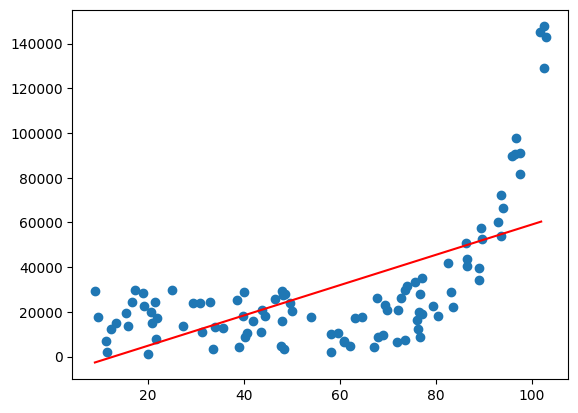

In [176]:
xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = linear.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')

Мы получаем такую картину.

Как и ожидалось, линейная модель не очень хорошо аппроксимирует наши данные. Для более точной оценки эффективности моделей выведем значение коэффициента детерминации:

In [177]:
linear.score(X, y)

0.37467360318911636

Мы видим, что это значение (37%) довольно низко. Можно сделать обоснованный вывод о том, что данная модель имеет низкую точность. 

Давайте попробуем построить полиномиальную регрессию второго порядка и посмотрим, улучшит ли это ситуацию. В библиотеке _sklearn_ нет отдельного класса для полиномиальных моделей. Вместо этого, введение полиномиальных признаков происходит путем преобразования данных. Для этого служит специальный класс:

In [178]:
from sklearn.preprocessing import PolynomialFeatures

Для преобразования данных в _sklearn_ создается отдельный объект. Чуть позже мы узнаем, зачем это нужно. Но поначалу работа с трансформацией данных может показаться немного неуклюжей. Но по другому действительно нельзя. Для начала надо создать объект трансформации - добавления полиномиальный признаков. При создании мы указываем степень полинома:

In [179]:
transformation = PolynomialFeatures(degree=2)

Теперь надо "обучить" объект трансформации на нашем датасете. Все объекты _sklearn_ специально сделаны очень похоже по интерфейсу на модели машинного обучения. Это очень полезно при их комбинировании в конвейеры. Об этом поговорим позже. Сейчас нужно "подстроить" объект трансформации под наши данные:

In [180]:
transformation.fit(X)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'



Теперь мы можем собственно преобразовать датасет:

In [181]:
X_2 = transformation.transform(X)


Мы всегда рекомендуем в таких случаях создавать именно новую переменную, а не перезаписывать имеющуюся. Это избавит нас от многих проблем при отладке и повторном выполнении кода. Давайте посмотрим на датасет, который получился в итоге:

In [182]:
X_2.shape
X_2[:5]

array([[1.00000000e+00, 9.65977805e+01, 9.33113119e+03],
       [1.00000000e+00, 4.80028921e+01, 2.30427765e+03],
       [1.00000000e+00, 4.79397558e+01, 2.29822018e+03],
       [1.00000000e+00, 4.78090258e+01, 2.28570295e+03],
       [1.00000000e+00, 6.97844271e+01, 4.86986627e+03]])

Мы видим, что он состоит из трех колонок. Первая - это автоматически добавляемая колонка, состоящая из одних единиц (так называемый bias). Ее добавление можно отключить. Вторая - это наш исходный _x_. А третья - это как раз $x^2$ - то есть полиномиальный признак.

Теперь мы можем обучить вторую модель на новой матрице признаков и уже знакомом векторе значений целевой переменной:

In [183]:
poly_2d = LinearRegression().fit(X_2, y)

Мы построили полиномиальную модель и хотим изобразить ее на графике. Для этого мы можем использовать уже имеющийся у нас массив _xx_. Но его теперь нужно преобразовать. Причем преобразовать именно так, как мы преобразовывали сам датасет. Именно для этого и служит объект трансформации. Единожды обучив его мы можем трансформировать единообразно сколько угодно разных датасетов. Применим еще раз нашу трансформацию:

In [184]:
xx_2d = transformation.transform(pd.DataFrame(xx))

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Вот теперь можно строить график:

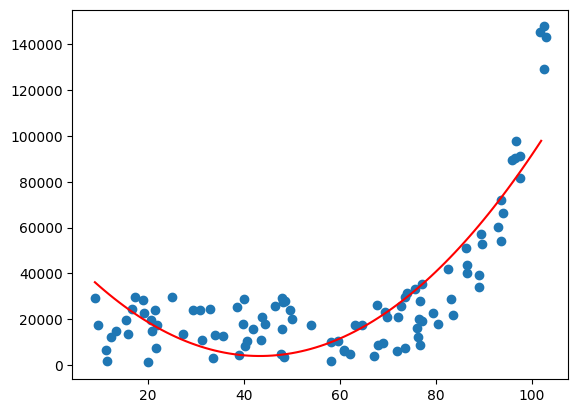

In [185]:
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='r')

На графике мы видим, что линия регрессии уже стала кривой - это и есть наша кривая второго порядка. Она, как видно, гораздо ближе к точкам, чем линейна функция. Это численно подтверждает и значение коэффициента детерминации второй модели:

In [186]:
poly_2d.score(X_2, y)

0.7359753787024842

Таким образом можно сделать вывод, что вторая модель (полиномиальная регрессия второго порядка) значительно лучше первой (линейной) описывает точки нашего набора данных. А значи эта модель будет давать гораздо более точные предсказания.

##### Классификация

В качестве второго примера разберем применение полиномиальных моделей для задач классификации. Вы увидите, что на практике это не сильно отличается от их применения в задачах регрессии. Для начала как всегда загрузим датасет:

In [187]:
data = pd.read_csv("data/gen_classification.csv",
                   index_col=0)

После визуального осмотра загруженных данных выделим матрицу атрибутов и вектор целевой переменной:

In [188]:
y = data.y
X = data.drop(["y"], axis=1)

Построим этот датасет на графике. При предварительном анализе данных мы должны были увидеть, что в целевой переменной содержится всего два значения. Это значит, что перед нами задача бинарной классификации:

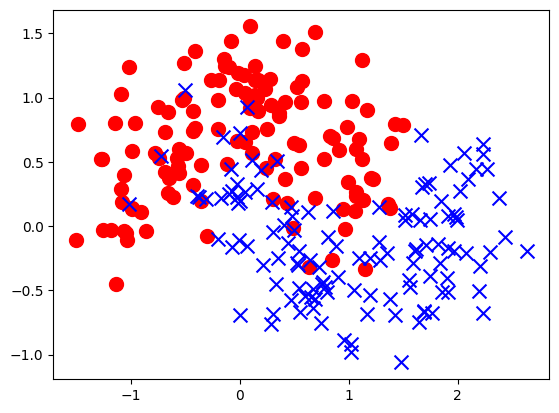

In [189]:
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

На графике ясно видно, что мы имеем дело с линейно неразделимым датасетом. Это может быть прямым показанием к использованию полиномиальной модели.

Но для начала, как всегда построим самую простую - линейную - модель. Так как мы имеем дело с классификацией, нам понадобится модель логистической регрессии. Для этого импортируем соответствующий класс:

In [190]:
from sklearn.linear_model import LogisticRegression


Создаем и сразу обучаем модель:

In [191]:
logistic = LogisticRegression().fit(X, y)

Пробуем изобразить модель на графике. Код построения контурного графика можно взять из предыдущих работ:

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


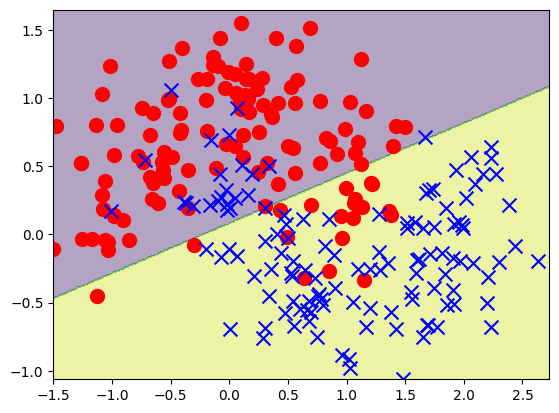

In [192]:
xx, yy = np.meshgrid(
    np.arange(X.iloc[:,0].min(), X.iloc[:,0].max()+0.1, 0.01),
    np.arange(X.iloc[:,1].min(), X.iloc[:,1].max()+0.1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))

Z = logistic.predict(XX).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

Мы увидим линейную границу принятия решений.

Очевидно, такая модель часто ошибается и не очень точна. Чтобы подтвердить такой вывод мы выведем значение метрики точности для нашей модели:

In [193]:
logistic.score(X, y)

0.832

Точность в 83% может показаться удовлетворительно, но из графика видно, насколько часто модель относит точки к неправильному классу. При анализе графика также можно предположить, что нелинейная (полиномиальная) граница принятия решения может нам существенно помочь.

Для построения нелинейной модели также создадим объект преобразования и применим его на нашей обучающей выборке (матрице атрибутов). Но сейчас мы сделаем все тоже самое короче. Для этого можно воспользоваться методом _fit\_transform()_, который подстраивает преобразование и сразу применяет его:

In [194]:
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)

Здесь мы применяем полиномиальные признаки третьей степени. Обратите внимание, что мы не включаем столбец из единиц - bias. Он нам не нужен, так как модель логистической регрессии сама внутри себя использует свободный коэффициент, так называемый intercept. Выведем форму получившегося массива:

In [195]:
X_3.shape

(250, 9)

Попробуйте объяснить самостоятельно, почему получилось именно 9 столбцов.Теперь мы можем создать объект логистической регрессии и сразу же обучить его на данных:

Теперь мы можем создать объект логистической регрессии и сразу же обучить его на данных:

In [196]:
class_3 = LogisticRegression().fit(X_3, y)

Изобразим получившуюся модель на графике. Обратите внимание, как мы используем объект преобразования и как мы повторно используем уже созданные служебные переменные:

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


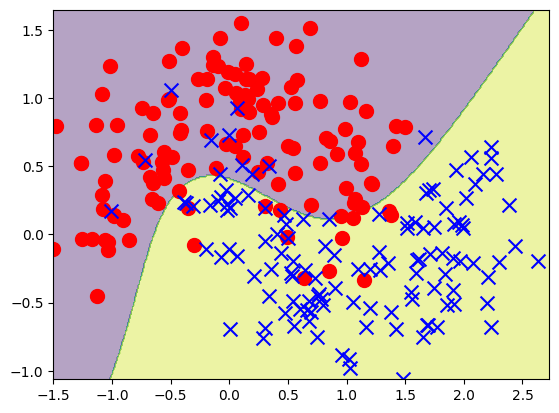

In [197]:
Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

На графике четко видно, что граница принятия решения принимает более сложную форму и за счет этого больше точек классифицируются верно. Это подтверждает и значение метрики точности данной модели:

In [198]:
class_3.score(X_3, y)

0.9

Таким образом, делаем вывод, что введение полиномиальных признаков также существенно повышает качество модели бинарной классификации.

##### Регрессия на реальных данных

Теперь попробуем применить полиномиальные модели для более сложной и более приближенной к реальной задаче. У нас есть датасет по продажам домов в одном округе США. Загрузим его и сразу выведем его форму:

In [ ]:
data_kc_prices = pd.read_csv("data/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

Мы видим, что в этом датасете 21 столбец. Мы еще не работали с такими объемными данными. Давайте посмотрим как выглядит этот набор данных:

In [ ]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Из этой таблицы нам вообще не понадобятся столбцы с датой и номером строки (идентификатором). Их мы уберем. А столбец с ценой будет у нас целевой переменной. Разделим наш датасет на атрибуты и целевую переменную:

In [ ]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)

Обратите внимание, что мы стали использовать более подробные названия переменных. При подробном анализе данных и машинном обучении вам неизбежно придется пробовать разные модели, разные способы обработки данных, разные датасеты. Также как мы сейчас в одном ноутбуке имеет несколько разных наборов данных, объектов моделей, объектов преобразования данных. Хорошей идеей будет не использовать каждый раз одни и те же короткие имена переменных. Во-первых, это не очень информативно и понятно. Взглянув на участок кода вы не поймете сразу, какую модель или какие данные здесь используются, надо либо анализировать широкий контекст кода, либо писать очень подробные комментарии, что не всегда удобно. Во-вторых, вы постоянно перезаписываете одни и те же переменные, что сильно затрудняет повторное использование кода частично по ячейкам. 

Поэтому мы будем использовать более сложные имена переменных, в которых отражен как сам характер переменной (что за объект внутри) так и то, к какой задаче он относится. Как структурировать имя переменной - вы должны решить сами, исходя из соображений удобства, привычки и читаемости.

Для того, чтобы убедиться в правильности разбиения данных, выведем формы получившихся массивов:

In [ ]:
X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

Основная сложность при обучении моделей на практике в том, что мы не можем изобразить все данные на графике. Сейчас у нас есть 18 колонок, которые невозможно одновременно построить в одной плоскости. Поэтому нам придется многие действия совершать "вслепую". Например, мы не знаем, какова зависимость между атрибутами и целевой переменной. Поэтому единственный разумный путь - начать строить модели от простого к сложному. Так что начнем с самой простой модели - линейной регрессии:

In [ ]:
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
reg_kc_multiple.score(X_kc_prices, y_kc_prices)

0.699747189010916

Мы сразу и обучили модель и оценили ее точность. Получилось значение 70%. Мы можем построить график отклонения реальные значений от предсказанных:

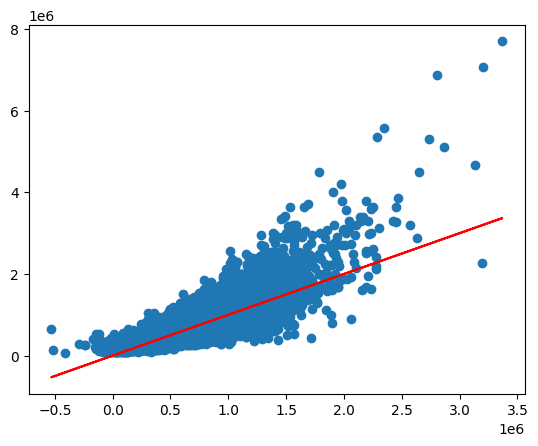

In [ ]:
y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')


Помните, что это не график самих данных. Здесь изображается только целевая переменная. Напомним, что чем больше разброс точек относительно центральной прямой, тем менее точная модель. В данном случае, мы видим, что отклонения явно носят систематический характер. Это прямое указание на то, что в этом случае может помочь полиномиальная модель. Давайте введем в модель полиномиальные признаки второго порядка:

In [ ]:
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices)

Здесь мы создали объект трансформации и применили его в одно действие. Для этого используется довольно редки в питоне "моржовый оператор" (walrus operator). Давайте для интереса выведем форму получившегося массива:

In [ ]:
X_3_kc_prices.shape

(21613, 1330)

Заметьте, насколько сильно увеличилось количество признаков в модели. При большом количестве атрибутов полиномиальные признаки нужно применять с большой осторожностью.

Теперь можно создать и обучить модель линейной регрессии:

In [ ]:
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

0.8326020796592741

Мы получили значительно более высокий уровень точности - 86,5%. Давайте изобразим отклонения получившейся модели на графике:

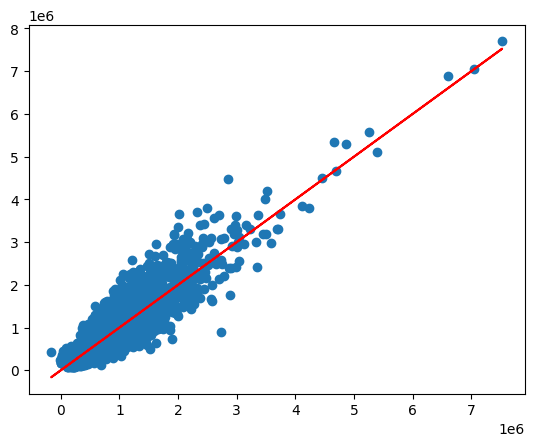

In [ ]:
y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')


Видно, что модель значительно улучшилась, так как точки сильно ближе к прямой. Таким образом, можно сделать вывод о том, что введение полиномиальных признаков второго порядка опять значительно улучшило модель.

##### Полиномиальной модели для King county (второго порядка)

Создаём полиномиальные признаки 2-й степени

In [ ]:
poly_kc_2 = PolynomialFeatures(degree=2, include_bias=False)
X_kc_poly2 = poly_kc_2.fit_transform(X_kc_prices)

Обучаем линейную регрессию

In [ ]:
reg_kc_poly2 = LinearRegression().fit(X_kc_poly2, y_kc_prices)
reg_kc_poly2.score(X_kc_poly2, y_kc_prices)

0.808449610717991

R² улучшился по сравнению с линейной моделью 70%, но ниже, чем у модели с degree=3 83% (которая переобучается).

График: предсказанные | реальные

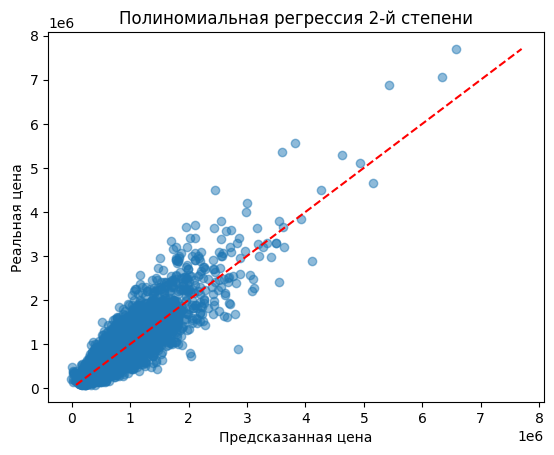

In [ ]:
y_pred_kc_poly2 = reg_kc_poly2.predict(X_kc_poly2)
plt.figure()
plt.scatter(y_pred_kc_poly2, y_kc_prices, alpha=0.5)
plt.plot([y_kc_prices.min(), y_kc_prices.max()], 
         [y_kc_prices.min(), y_kc_prices.max()], 'r--')
plt.xlabel('Предсказанная цена')
plt.ylabel('Реальная цена')
plt.title('Полиномиальная регрессия 2-й степени')
plt.show()

### Контрольные вопросы

**1. В чем заключается суть метода множественной регрессии?**  
Множественная регрессия — это модель, которая описывает зависимость целевой переменной y от нескольких факторов x_1, x_2, ..., x_n в виде линейной комбинации:  
y = w_0 + w_1 x_1 + ... + w_n x_n.  
Коэффициенты w_i подбираются методом наименьших квадратов – минимизацией суммы квадратов разностей между реальными и предсказанными значениями. Это позволяет учесть совместное влияние всех признаков.

**2. Какие основные недостатки применения полиномиальных признаков на практике?**  
- число признаков резко возрастает (для n исходных признаков и степени d – примерно C(n+d, d) комбинаций).  
- Переобучение 
- Высокая вычислительная сложность: требуется больше оперативной памяти и времени на обучение.  

**3. В каких случая введение полиномиальных признаков может быть полезным?**  
Когда истинная зависимость между признаками и целевой переменной нелинейна, но при этом не слишком сложна (например, квадратичная, кубическая). Полиномиальные признаки позволяют линейной модели «уловить» эту нелинейность без перехода к более сложным алгоритмам (нейронные сети, деревья). Особенно эффективно при небольшом количестве исходных признаков.

**4. Как растет требование к объему оперативной памяти при введении полиномиальных признаков?**  
Требование к памяти растёт комбинаторно (полиномиально от степени). Для n исходных признаков и степени d число полиномиальных признаков равно (n+d)!/(n! d!). Например, при n=18 и d=2 получается около 190 признаков, при d=3 – уже около 1330. Это может быстро привести к нехватке оперативной памяти, особенно при большом числе объектов.

**5. Почему при введении полиномиальных признаков нужно добавить все комбинации атрибутов до заданной степени?**  
Потому что заранее неизвестно, какие именно взаимодействия значимы: может быть важен не только квадрат признака, но и его произведение с другим признаком. Добавление всех комбинаций позволяет модели самой «выбрать» нужные члены (через величину коэффициентов или регуляризацию). Пропуск некоторых комбинаций может привести к потере важных нелинейных эффектов.

**6. Почему на последнем графике линия получается прямая, хотя мы используем нелинейную модель?**  
Этот график изображает не зависимость y от x, а сопоставление предсказанных значений с реальными. Прямая линия y_pred = y_real – это линия идеального предсказания. Чем ближе точки к этой прямой, тем точнее модель. Нелинейность модели проявляется в том, как предсказание зависит от исходных признаков, но на данном графике она не видна – здесь только сравнение предсказанных и истинных значений.